In [1]:
# Importar bibliotecas e módulos
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# Carregar o dataset
raw_data = pd.read_csv('Student_Performance.csv')

In [3]:
raw_data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
raw_data.info()
raw_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [5]:
raw_data['Extracurricular Activities'] = raw_data['Extracurricular Activities'].map({'Yes':1,'No':0})

In [6]:
raw_data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [7]:
# Quantidade de valores infinitos por coluna
print(raw_data.isin([float('inf'), -float('inf')]).sum())

# Quantidade de valores NaN por coluna
print(raw_data.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [8]:
features = raw_data.drop(columns = ['Performance Index'])
target = raw_data['Performance Index']

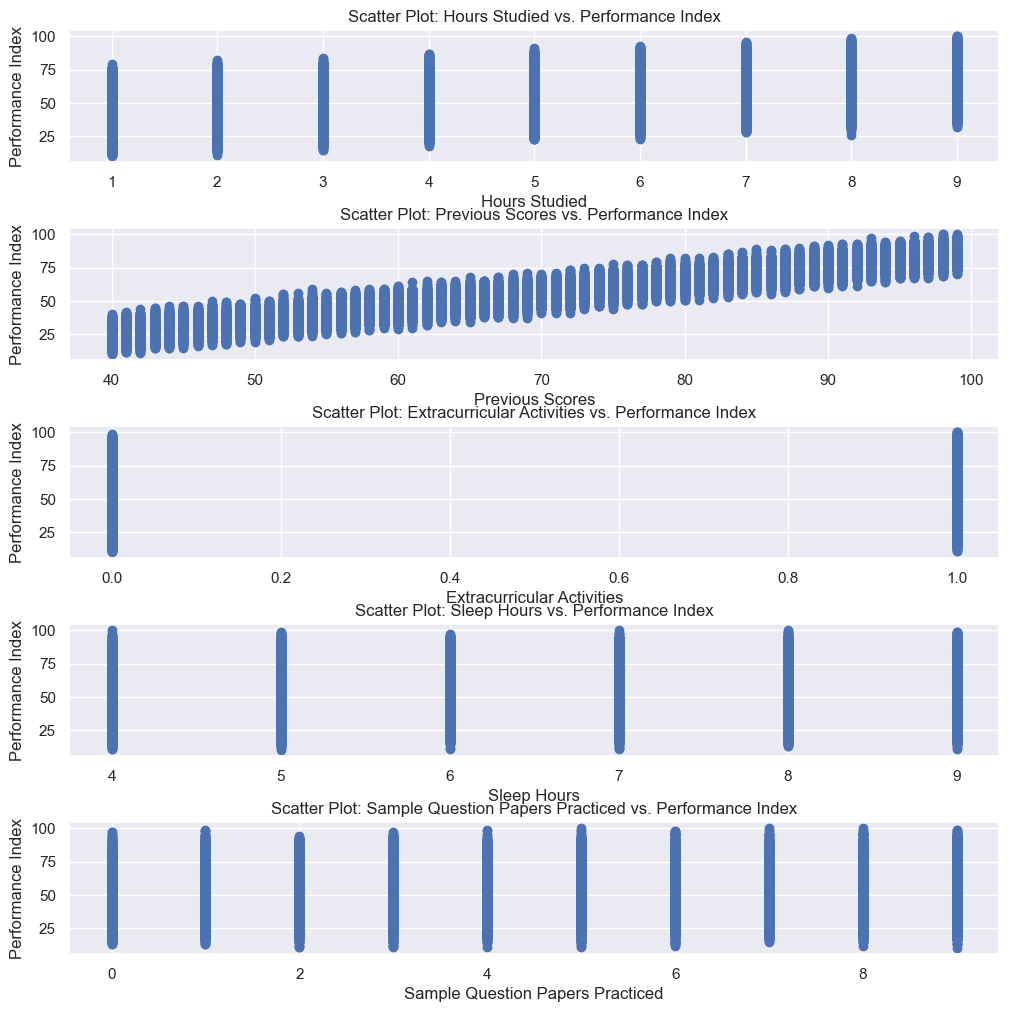

In [9]:
# Obter a lista de colunas, excluindo a coluna "Performance Index"
cols = [col for col in raw_data.columns if col != 'Performance Index']

# Criar a figura e os subplots
fig, axes = plt.subplots(len(cols), 1, figsize=(12, 12))

# Iterar sobre as colunas e criar os scatter plots
for i, col in enumerate(cols):
    axes[i].scatter(raw_data[col], raw_data['Performance Index'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Performance Index')
    axes[i].set_title(f'Scatter Plot: {col} vs. Performance Index')

# Ajustar o espaçamento entre os subplots
plt.subplots_adjust(hspace=0.5)

# Exibir o gráfico
plt.show()

In [10]:
features.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300
std,2.589309,17.343152,0.499998,1.695863,2.867348
min,1.000000,40.000000,0.000000,4.000000,0.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000


In [11]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column
    
    Args:
      X (ndarray (m,n))     : input data, m examples, n features
      
    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    # find the mean of each column/feature
    mu     = np.mean(X, axis=0)                 # mu will have shape (n,)
    # find the standard deviation of each column/feature
    sigma  = np.std(X, axis=0)                  # sigma will have shape (n,)
    # element-wise, subtract mu for that column from each example, divide by std for that column
    X_norm = (X - mu) / sigma      

    return (X_norm, mu, sigma)

In [12]:
# normalize the original features
X_set_norm, X_mu, X_sigma = zscore_normalize_features(features)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")

X_mu = Hours Studied                        4.9929
Previous Scores                     69.4457
Extracurricular Activities           0.4948
Sleep Hours                          6.5306
Sample Question Papers Practiced     4.5833
dtype: float64, 
X_sigma = Hours Studied                        2.589179
Previous Scores                     17.342285
Extracurricular Activities           0.499973
Sleep Hours                          1.695778
Sample Question Papers Practiced     2.867204
dtype: float64


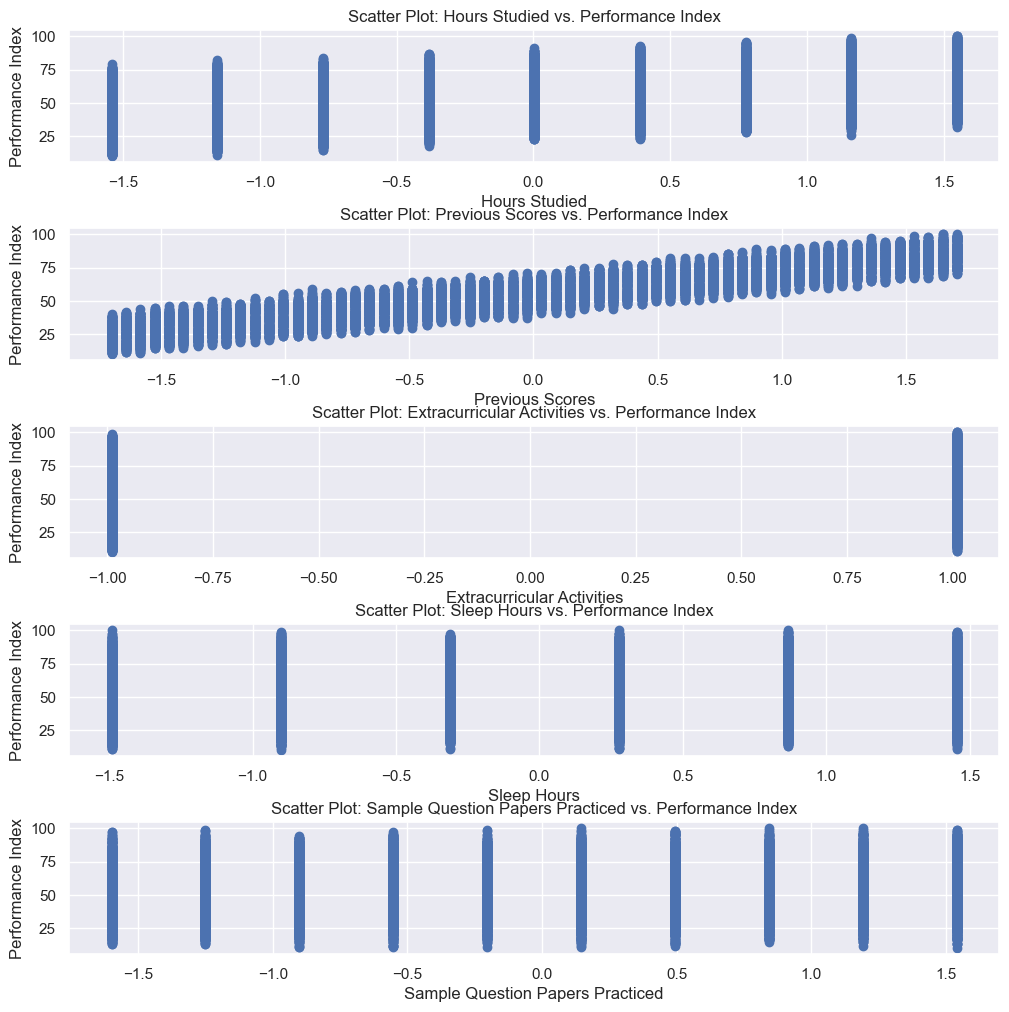

In [13]:
# Obter a lista de colunas, excluindo a coluna "Performance Index"
cols = [col for col in X_set_norm.columns]

# Criar a figura e os subplots
fig, axes = plt.subplots(len(cols), 1, figsize=(12, 12))

# Iterar sobre as colunas e criar os scatter plots
for i, col in enumerate(cols):
    axes[i].scatter(X_set_norm[col], target)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Performance Index')
    axes[i].set_title(f'Scatter Plot: {col} vs. Performance Index')

# Ajustar o espaçamento entre os subplots
plt.subplots_adjust(hspace=0.5)

# Exibir o gráfico
plt.show()

In [14]:
#x_train, x_test, y_train, y_test = train_test_split(X_normalized, target, test_size=0.2, random_state=365)
x_train, x_test, y_train, y_test = train_test_split(X_set_norm, target, test_size=0.2, random_state=365)

In [15]:
# Create a linear regression object
reg = LinearRegression()

In [16]:
# realizando a regressão de treino
x = sm.add_constant(x_train)
reg_lin = sm.OLS(y_train,x)
results_lin = reg_lin.fit()
# Retornando a tabela de resultado da regressão
results_lin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Performance Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.407e+05
Date:                Fri, 28 Jun 2024   Prob (F-statistic):               0.00
Time:                        11:05:17   Log-Likelihood:                -17049.
No. Observations:                8000   AIC:                         3.411e+04
Df Residuals:                    7994   BIC:                         3.415e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               55.2214      0.023   2421.881      0.000      55.177      55.266
Hours Studied                        7.3830      0.023    324.162      0.000       7.338       7.428
Previous Scores                     17.6852      0.023    775.783      0.000      17.640      17.730
Extracurricular Activities           0.3121      0.023     13.685      0.000       0.267       0.357
Sleep Hours                          0.8072      0.023     35.418      0.000       0.762       0.852
Sample Question Papers Practiced     0.5539      0.023     24.161      0.000       0.509       0.599
==============================================================================
Omnibus:                        1.978   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.372   Jarque-Bera (JB):                1.957
Skew:                           0.022   Prob(JB):                        0.376
Kurtosis:                       3.062   Cond. No.                         1.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# Criar o modelo de regressão linear
x_train_const = sm.add_constant(x_train)
reg_lin = sm.OLS(y_train, x_train_const).fit()

# Gerar valores previstos para os dados de treino e teste
y_train_pred = reg_lin.predict(x_train_const)
y_test_pred = reg_lin.predict(sm.add_constant(x_test))
